# 2HW. Классификация цифр SVHN

## 1. Данные

Цветные изображения цифр из номеров домов. В `.mat` файлах: изображения — `(32, 32, 3, N)`, метки — `(N, 1)`.

In [10]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

HW_DIR = Path("2HW")
if not HW_DIR.exists():
    HW_DIR = Path(".")

TRAIN_PATH = HW_DIR / "train_32x32.mat"
TEST_PATH = HW_DIR / "test_32x32.mat"

if str(HW_DIR) not in sys.path:
    sys.path.append(str(HW_DIR))

from simple_nn import (  # noqa: E402
    Adam,
    BatchNormLayer,
    CrossEntropyLoss,
    FullyConnectedLayer,
    Momentum,
    ReluLayer,
    SGD,
    Sequential,
    accuracy,
    evaluate,
    gradient_check_layer,
    gradient_check_model,
    train_epoch,
)

RANDOM_STATE = 122
rng = np.random.default_rng(RANDOM_STATE)


In [11]:
def load_svhn_mat(path):
    raw = loadmat(path)
    X = raw["X"].transpose(3, 0, 1, 2)
    y = raw["y"].reshape(-1).astype(int)
    y[y == 10] = 0
    return X, y


X_train_images, y_train_all = load_svhn_mat(TRAIN_PATH)
X_test_images, y_test = load_svhn_mat(TEST_PATH)

print("Train images:", X_train_images.shape, X_train_images.dtype)
print("Train labels:", y_train_all.shape, y_train_all.min(), y_train_all.max())
print("Test images:", X_test_images.shape, X_test_images.dtype)
print("Test labels:", y_test.shape, y_test.min(), y_test.max())


Train images: (73257, 32, 32, 3) uint8
Train labels: (73257,) 0 9
Test images: (26032, 32, 32, 3) uint8
Test labels: (26032,) 0 9


### 1.1. Баланс классов

In [12]:
def label_counts(y, split):
    counts = pd.Series(y, name="digit").value_counts().sort_index()
    return pd.DataFrame({"digit": counts.index, "count": counts.values, "split": split})


class_balance = pd.concat(
    [label_counts(y_train_all, "train"), label_counts(y_test, "test")],
    ignore_index=True,
)
class_balance


,digit,count,split
0,0,4948,train
1,1,13861,train
2,2,10585,train
3,3,8497,train
4,4,7458,train
5,5,6882,train
6,6,5727,train
7,7,5595,train
8,8,5045,train
9,9,4659,train


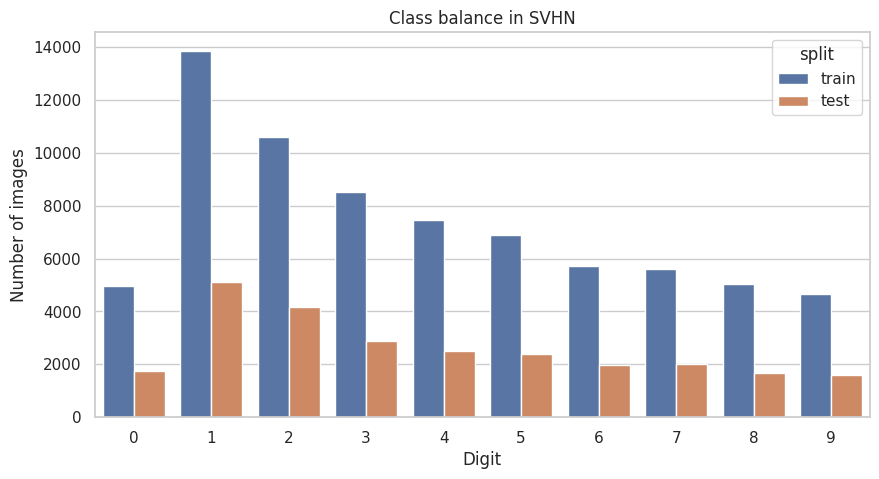

In [13]:
sns.barplot(data=class_balance, x="digit", y="count", hue="split")
plt.title("Class balance in SVHN")
plt.xlabel("Digit")
plt.ylabel("Number of images")
plt.show()


### 1.2. Примеры изображений

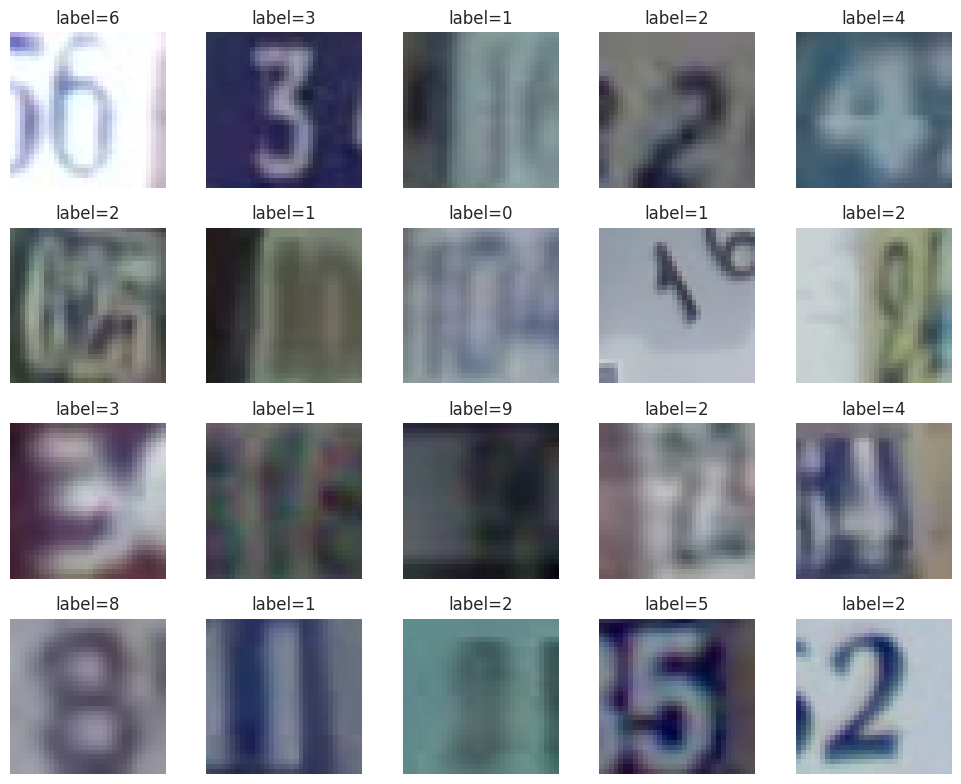

In [14]:
sample_ids = rng.choice(len(X_train_images), size=20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for ax, image_id in zip(axes.ravel(), sample_ids):
    ax.imshow(X_train_images[image_id])
    ax.set_title(f"label={y_train_all[image_id]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Подготовка данных

Усредняем RGB-каналы, делим на 255 и разворачиваем изображение в 1024 признака. Из train выделяем 10 000 примеров для validation. Среднее и стандартное отклонение считаем только по оставшемуся train.

In [15]:
def images_to_features(images):
    grayscale = images.astype(np.float32).mean(axis=3) / 255.0
    return grayscale.reshape(len(images), -1)


X_train_features_all = images_to_features(X_train_images)
X_test_features = images_to_features(X_test_images)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_features_all,
    y_train_all,
    test_size=10_000,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)

feature_mean = X_train_raw.mean(axis=0, keepdims=True)
feature_std = X_train_raw.std(axis=0, keepdims=True) + 1e-6

X_train = (X_train_raw - feature_mean) / feature_std
X_val = (X_val_raw - feature_mean) / feature_std
X_test = (X_test_features - feature_mean) / feature_std

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (63257, 1024) (63257,)
Validation: (10000, 1024) (10000,)
Test: (26032, 1024) (26032,)


In [16]:
pixel_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "mean": [X_train.mean(), X_val.mean(), X_test.mean()],
        "std": [X_train.std(), X_val.std(), X_test.std()],
        "min": [X_train.min(), X_val.min(), X_test.min()],
        "max": [X_train.max(), X_val.max(), X_test.max()],
    }
)
pixel_summary


,split,mean,std,min,max
0,train,-0.000003,0.999998,-2.461806,3.136271
1,validation,-0.010305,0.996342,-2.396762,3.136271
2,test,0.032335,1.134294,-2.463274,3.136271


## 3. Проверка градиентов

Разностная проверка перед обучением: сеть `FC → ReLU → FC` и отдельные слои FC, ReLU, BatchNorm.

In [17]:
small_rng = np.random.default_rng(RANDOM_STATE)
X_small = small_rng.normal(size=(6, 4))
y_small = np.array([0, 1, 2, 1, 0, 2])

small_model = Sequential(
    [
        FullyConnectedLayer(4, 5, rng=small_rng),
        ReluLayer(),
        FullyConnectedLayer(5, 3, rng=small_rng),
    ]
)
model_check = pd.DataFrame(
    gradient_check_model(
        small_model,
        CrossEntropyLoss(),
        X_small,
        y_small,
        l2=1e-3,
        num_checks=5,
    )
)
model_check.groupby("parameter")["relative_error"].max().reset_index()


,parameter,relative_error
0,layer0.W,4.019515e-10
1,layer0.b,1.506616e-09
2,layer2.W,1.193071e-09
3,layer2.b,4.170173e-10


In [18]:
layer_rng = np.random.default_rng(RANDOM_STATE)
layer_checks = []

fc_layer = FullyConnectedLayer(4, 3, rng=layer_rng)
layer_checks.extend(gradient_check_layer(fc_layer, layer_rng.normal(size=(5, 4)), layer_rng.normal(size=(5, 3))))

relu_layer = ReluLayer()
layer_checks.extend(gradient_check_layer(relu_layer, layer_rng.normal(size=(5, 4)), layer_rng.normal(size=(5, 4))))

bn_layer = BatchNormLayer(4)
layer_checks.extend(gradient_check_layer(bn_layer, layer_rng.normal(size=(6, 4)), layer_rng.normal(size=(6, 4))))

layer_check_df = pd.DataFrame(layer_checks)
layer_check_df.groupby("parameter")["relative_error"].max().reset_index()


,parameter,relative_error
0,W,5.130746e-10
1,b,2.256341e-11
2,beta,8.709310e-12
3,gamma,1.383487e-11
4,input,5.961493e-10


Ориентир для относительной ошибки — менее `1e-5`.

## 4. Обучение

Архитектура: `FC → ReLU → FC`. В варианте с BatchNorm нормализация стоит перед ReLU.

In [19]:
INPUT_DIM = X_train.shape[1]
NUM_CLASSES = 10
HIDDEN_DIM = 32
BATCH_SIZE = 1024
L2 = 1e-4


def make_model(hidden_dim=HIDDEN_DIM, use_batchnorm=False, random_state=RANDOM_STATE):
    model_rng = np.random.default_rng(random_state)
    layers = [FullyConnectedLayer(INPUT_DIM, hidden_dim, rng=model_rng)]
    if use_batchnorm:
        layers.append(BatchNormLayer(hidden_dim))
    layers.extend(
        [
            ReluLayer(),
            FullyConnectedLayer(hidden_dim, NUM_CLASSES, rng=model_rng),
        ]
    )
    return Sequential(layers)


def make_optimizer(name, learning_rate):
    if name == "SGD":
        return SGD(learning_rate=learning_rate)
    if name == "Momentum":
        return Momentum(learning_rate=learning_rate, momentum=0.9)
    if name == "Adam":
        return Adam(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {name}")


def train_model(model, optimizer, epochs, batch_size=BATCH_SIZE, l2=L2, random_state=RANDOM_STATE):
    loss_fn = CrossEntropyLoss()
    history = []
    started_at = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_metrics = train_epoch(
            model,
            loss_fn,
            optimizer,
            X_train,
            y_train,
            batch_size=batch_size,
            l2=l2,
            rng=random_state + epoch,
        )
        val_metrics = evaluate(model, loss_fn, X_val, y_val, batch_size=batch_size, l2=l2)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "elapsed_sec": time.perf_counter() - started_at,
            }
        )

    return pd.DataFrame(history)


### 4.1. Подбор learning rate

Для SGD проверяем `0.1`, `0.03`, `0.01`: по 20 эпох, выбор по validation accuracy.

In [20]:
LR_GRID = [0.1, 0.03, 0.01]
TUNING_EPOCHS = 20

tuning_histories = []
tuning_summary = []

for learning_rate in LR_GRID:
    model = make_model(use_batchnorm=False, random_state=RANDOM_STATE)
    optimizer = make_optimizer("SGD", learning_rate)
    history = train_model(model, optimizer, epochs=TUNING_EPOCHS)
    history["learning_rate"] = learning_rate
    tuning_histories.append(history)
    best_row = history.sort_values("val_accuracy", ascending=False).iloc[0]
    tuning_summary.append(
        {
            "learning_rate": learning_rate,
            "best_val_accuracy": best_row["val_accuracy"],
            "best_val_loss": best_row["val_loss"],
            "elapsed_sec": history["elapsed_sec"].iloc[-1],
        }
    )

tuning_summary = pd.DataFrame(tuning_summary).sort_values("best_val_accuracy", ascending=False)
best_lr = float(tuning_summary.iloc[0]["learning_rate"])
tuning_summary


,learning_rate,best_val_accuracy,best_val_loss,elapsed_sec
0,0.10,0.7475,0.883689,10.818626
1,0.03,0.7156,0.991632,10.269647
2,0.01,0.6386,1.253969,10.203135


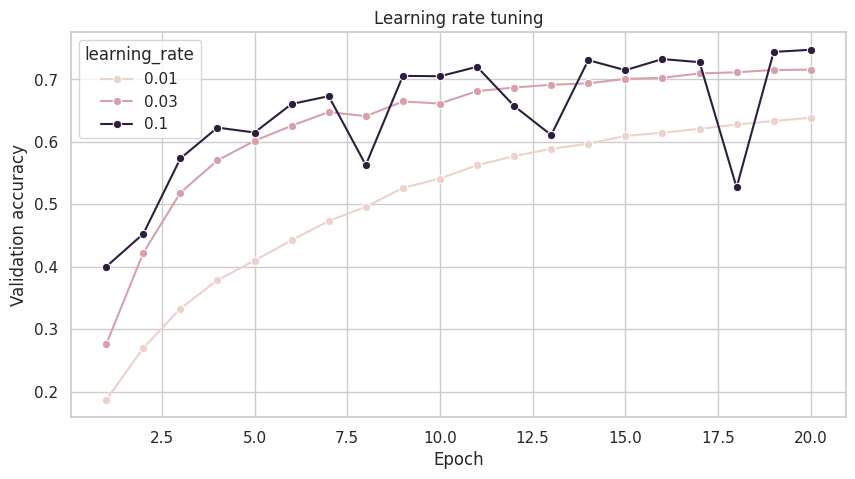

Best learning rate: 0.1


In [21]:
tuning_plot = pd.concat(tuning_histories, ignore_index=True)
sns.lineplot(data=tuning_plot, x="epoch", y="val_accuracy", hue="learning_rate", marker="o")
plt.title("Learning rate tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.show()

print("Best learning rate:", best_lr)


### 4.2. Оптимизаторы и BatchNorm

SGD, Momentum и Adam; Momentum и Adam — также с BatchNorm. Разбиение данных и L2 одинаковые.

In [22]:
COMPARISON_EPOCHS = 20
model_configs = [
    {"model_name": "SGD", "optimizer": "SGD", "learning_rate": best_lr, "batchnorm": False},
    {"model_name": "Momentum", "optimizer": "Momentum", "learning_rate": best_lr, "batchnorm": False},
    {"model_name": "Adam", "optimizer": "Adam", "learning_rate": 1e-3, "batchnorm": False},
    {
        "model_name": "Momentum + BatchNorm",
        "optimizer": "Momentum",
        "learning_rate": best_lr,
        "batchnorm": True,
    },
    {"model_name": "Adam + BatchNorm", "optimizer": "Adam", "learning_rate": 1e-3, "batchnorm": True},
]

comparison_histories = []
trained_models = {}

for config in model_configs:
    model = make_model(use_batchnorm=config["batchnorm"], random_state=RANDOM_STATE)
    optimizer = make_optimizer(config["optimizer"], config["learning_rate"])
    history = train_model(model, optimizer, epochs=COMPARISON_EPOCHS)
    history = history.assign(**config)
    comparison_histories.append(history)
    trained_models[config["model_name"]] = model

comparison_history = pd.concat(comparison_histories, ignore_index=True)
comparison_summary = (
    comparison_history.sort_values(["model_name", "val_accuracy"], ascending=[True, False])
    .groupby("model_name")
    .head(1)
    .sort_values("val_accuracy", ascending=False)
)
comparison_summary[
    ["model_name", "optimizer", "learning_rate", "batchnorm", "val_loss", "val_accuracy", "elapsed_sec"]
]


,model_name,optimizer,learning_rate,batchnorm,val_loss,val_accuracy,elapsed_sec
79,Momentum + BatchNorm,Momentum,0.100,True,7.971866e-01,0.7778,12.147382
58,Adam,Adam,0.001,False,8.074049e-01,0.7699,10.970618
97,Adam + BatchNorm,Adam,0.001,True,8.271090e-01,0.7679,10.186203
19,SGD,SGD,0.100,False,8.836889e-01,0.7475,11.398206
35,Momentum,Momentum,0.100,False,1.167934e+131,0.1873,8.699612


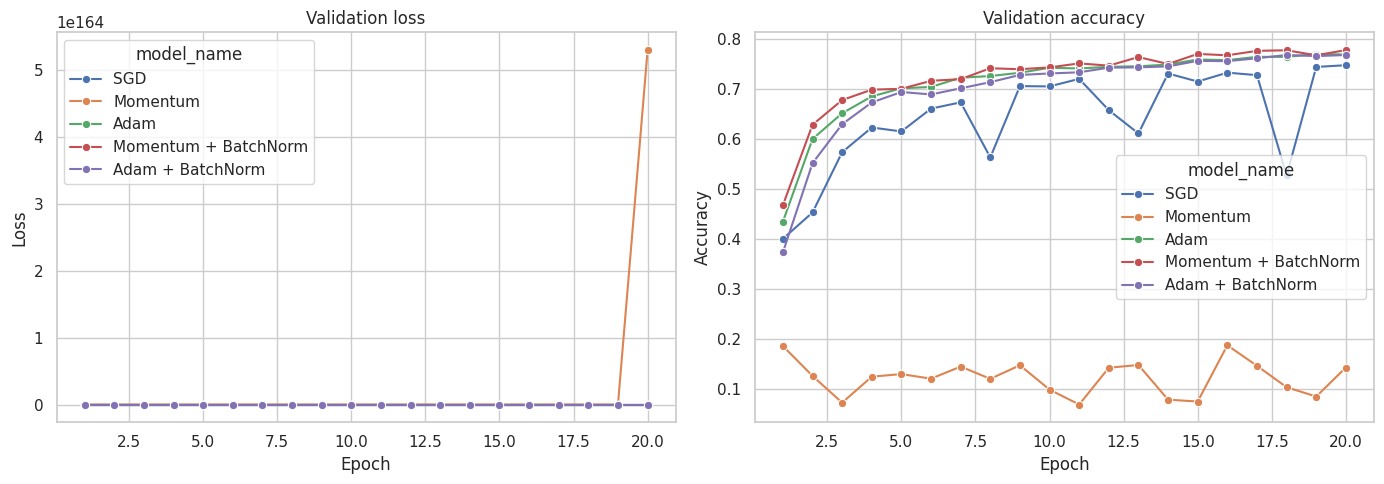

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=comparison_history,
    x="epoch",
    y="val_loss",
    hue="model_name",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(
    data=comparison_history,
    x="epoch",
    y="val_accuracy",
    hue="model_name",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


## 5. Тест

Оцениваем конфигурацию с лучшей validation accuracy.

In [24]:
best_model_name = comparison_summary.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

test_metrics = evaluate(best_model, CrossEntropyLoss(), X_test, y_test, batch_size=BATCH_SIZE, l2=L2)
y_test_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Test loss:", round(test_metrics["loss"], 4))
print("Test accuracy:", round(test_metrics["accuracy"], 4))


Best model: Momentum + BatchNorm
Test loss: 0.9313
Test accuracy: 0.7527


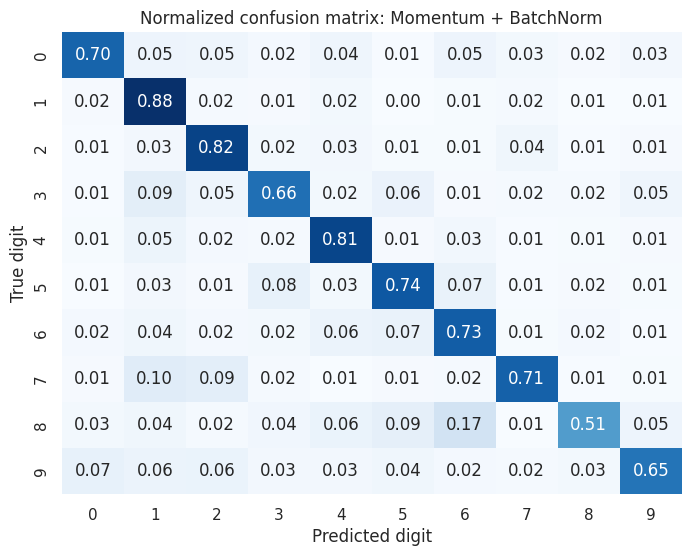

In [25]:
confusion = pd.crosstab(
    pd.Series(y_test, name="true"),
    pd.Series(y_test_pred, name="predicted"),
    normalize="index",
)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title(f"Normalized confusion matrix: {best_model_name}")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.show()


## 6. Результат

Momentum + BatchNorm: accuracy на validation — **77,26%**, на test — **74,70%**.